
# AmbiCode-Eval — Internal Result Report

*Audience: project team. Free to be exploratory.*

This notebook is the team-facing deep-dive into the v2-full benchmark
evaluation (5 models × 48 items × n=5 × T=0.8). It lives next to the
milestone analysis notebook, but is intentionally rougher: more raw tables,
more diagnostic plots, more "huh, that's weird" callouts.

**Companion notebook:** [`milestone_analysis.ipynb`](./milestone_analysis.ipynb) — the polished, poster-facing version.

**What's in here that's *not* in the milestone notebook:**

- Sanity checks (do the choice-decomposition counts add up? are there missing samples?)
- Per-model raw distributions
- A complete gallery of every AC sample (only ~10–15 across all models — small enough to enumerate)
- A curated EA gallery (what assumptions do models *actually* declare?)
- Failure-mode taxonomy applied to the "neither" cases (parse / runtime / wrong-read / DS-1000 schema)
- Hardest / easiest / most-variable items
- Sonnet anomaly drill-down with side-by-side code from 5 models
- Latency profile (per-model wall-clock cost)
- B-pickup analysis (when does anyone actually pick interpretation B?)

> ⚠️ Numbers in this notebook should match the milestone notebook to within rounding. If they don't, stop and figure out why.


In [1]:

# ── Setup ──────────────────────────────────────────────────────────────────
import json
import re
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.plot_style import (
    setup_style, MODEL_COLORS, MODEL_ORDER, BEHAVIOR_COLORS, DIVERGING_CMAP,
    model_palette, shorten_model_name,
)
setup_style()

DATA = ROOT / "data" / "results" / "milestone"
RESULTS = ROOT / "data" / "results"

summary    = json.loads((DATA / "summary.json").read_text())
per_item   = pd.read_csv(DATA / "per_item.csv")
by_type    = pd.read_csv(DATA / "by_type.csv")
by_risk    = pd.read_csv(DATA / "by_risk.csv")
by_source  = pd.read_csv(DATA / "by_source.csv")

MODELS = [m for m in MODEL_ORDER if m in summary["models"]]
print(f"Loaded {len(MODELS)} models: {MODELS}")


Loaded 5 models: ['gpt-5.5', 'claude-sonnet', 'claude-opus', 'gemini-3.1-pro', 'deepseek-v4-pro']


In [2]:

# Locate the latest classified_<model>_<ts>.jsonl per milestone model and load
# sample-level records. We need them for behavior gallery + failure dissection.

_TS_RE = re.compile(r"_(\d{8}_\d{6})\.jsonl$")

def _ts(p: Path) -> str:
    m = _TS_RE.search(p.name)
    return m.group(1) if m else ""

def _load_jsonl(path: Path) -> list[dict]:
    rows = []
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        r = json.loads(line)
        if r.get("task_id", "").startswith("SUMMARY"):
            continue
        rows.append(r)
    return rows


classified_files: dict[str, Path] = {}
for m in MODELS:
    safe = m.replace("/", "_")
    candidates = sorted(RESULTS.glob(f"classified_{safe}_*.jsonl"), key=_ts, reverse=True)
    for c in candidates:
        n = sum(1 for ln in c.read_text().splitlines()
                if ln.strip() and not json.loads(ln).get("task_id", "").startswith("SUMMARY"))
        if n == summary["benchmark_size"]:
            classified_files[m] = c
            break

# Map: model -> list of items (each item has `samples` list)
classified: dict[str, list[dict]] = {m: _load_jsonl(p) for m, p in classified_files.items()}

# Long DataFrame at the SAMPLE level (for gallery + failure dissection)
def to_sample_df():
    rows = []
    for m, items in classified.items():
        for it in items:
            for s in it["samples"]:
                rows.append({
                    "model": m,
                    "task_id": it["task_id"],
                    "anchor_task_id": it.get("anchor_task_id", ""),
                    "source": it["source"],
                    "ambiguity_type": it["ambiguity_type"],
                    "risk_level": it["risk_level"],
                    "interpretation_a": it.get("interpretation_a", ""),
                    "interpretation_b": it.get("interpretation_b", ""),
                    "perturbed_prompt": it.get("perturbed_prompt", ""),
                    "sample": s.get("sample"),
                    "passed_a": s.get("passed_a", False),
                    "passed_b": s.get("passed_b", False),
                    "behavior_label": s.get("behavior_label", ""),
                    "behavior_q1_question": s.get("behavior_q1_question", False),
                    "behavior_q2_code": s.get("behavior_q2_code", False),
                    "behavior_q3_assumption": s.get("behavior_q3_assumption", False),
                    "behavior_rationale": s.get("behavior_rationale", ""),
                    "raw_response": s.get("raw_response", ""),
                    "generated_code": s.get("generated_code", ""),
                    "prose": s.get("prose", ""),
                    "stderr_a": s.get("stderr_a", ""),
                    "stderr_b": s.get("stderr_b", ""),
                    "exit_code_a": s.get("exit_code_a", -1),
                    "exit_code_b": s.get("exit_code_b", -1),
                    "timed_out_a": s.get("timed_out_a", False),
                    "timed_out_b": s.get("timed_out_b", False),
                    "latency_s": s.get("latency_s", 0.0),
                })
    return pd.DataFrame(rows)

samples = to_sample_df()
print(f"Sample-level frame: {len(samples)} rows  ({samples.groupby('model').size().to_dict()})")


Sample-level frame: 1200 rows  ({'claude-opus': 240, 'claude-sonnet': 240, 'deepseek-v4-pro': 240, 'gemini-3.1-pro': 240, 'gpt-5.5': 240})



## 1. Data inventory + sanity checks

Goal: be sure we have what we think we have, and that the choice
decomposition counts (chose_a + chose_b + both + neither) add up to
n_samples for every (model, item).


In [3]:

# 1.1 Coverage table
inv = (per_item.groupby("model")
                 .agg(items=("task_id", "nunique"),
                      total_samples=("n_samples", "sum"),
                      mbpp=("source", lambda s: (s == "mbpp").sum()),
                      ds1000=("source", lambda s: (s == "ds1000").sum()),
                      humaneval=("source", lambda s: (s == "humaneval").sum()))
                 .reindex(MODELS))
print("Per-model coverage:")
inv


Per-model coverage:


,items,total_samples,mbpp,ds1000,humaneval
model,,,,,
gpt-5.5,48,240,19,27,2
claude-sonnet,48,240,19,27,2
claude-opus,48,240,19,27,2
gemini-3.1-pro,48,240,19,27,2
deepseek-v4-pro,48,240,19,27,2


In [4]:

# 1.2 Choice decomposition sanity:
# chose_a + chose_b + pass_both + pass_neither should equal n_samples per row.
sanity = per_item.copy()
sanity["sum_decomp"] = (sanity["chose_a_count"] + sanity["chose_b_count"]
                       + sanity["pass_both_count"] + sanity["pass_neither_count"])
mismatches = sanity[sanity["sum_decomp"] != sanity["n_samples"]]
if mismatches.empty:
    print("✓  Choice decomposition adds up to n_samples for ALL (model, item) rows.")
else:
    print(f"✗  {len(mismatches)} rows where decomposition ≠ n_samples:")
    print(mismatches[["model", "task_id", "sum_decomp", "n_samples"]].head(10).to_string(index=False))


✓  Choice decomposition adds up to n_samples for ALL (model, item) rows.


In [5]:

# 1.3 Behavior labels sanity:
# behavior_<lbl> across {SA, EA, AC, unclassifiable, error} should sum to n_samples.
b_cols = [c for c in per_item.columns if c.startswith("behavior_")]
sanity = per_item.copy()
sanity["sum_b"] = sanity[b_cols].sum(axis=1)
mismatches = sanity[sanity["sum_b"] != sanity["n_samples"]]
if mismatches.empty:
    print(f"✓  Behavior labels sum to n_samples across {b_cols}")
else:
    print(f"✗  {len(mismatches)} rows where behavior labels don't sum:")
    print(mismatches[["model", "task_id", "sum_b", "n_samples"] + b_cols].head(5))

# Also a quick: any judge errors?
print()
err_count = per_item["behavior_error"].sum()
unclass_count = per_item["behavior_unclassifiable"].sum()
total_samp = per_item["n_samples"].sum()
print(f"behavior=error      : {err_count}/{total_samp}  ({err_count/total_samp*100:.1f}%)")
print(f"behavior=unclassifiable: {unclass_count}/{total_samp}  ({unclass_count/total_samp*100:.1f}%)")


✓  Behavior labels sum to n_samples across ['behavior_SA', 'behavior_EA', 'behavior_AC', 'behavior_unclassifiable', 'behavior_error']

behavior=error      : 0/1200  (0.0%)
behavior=unclassifiable: 14/1200  (1.2%)



## 2. Per-model aggregate distributions

What does the *distribution* of per-item baseline pass rate, pass_either, and tax look like for each model? Headline numbers are means; here we look at spread.


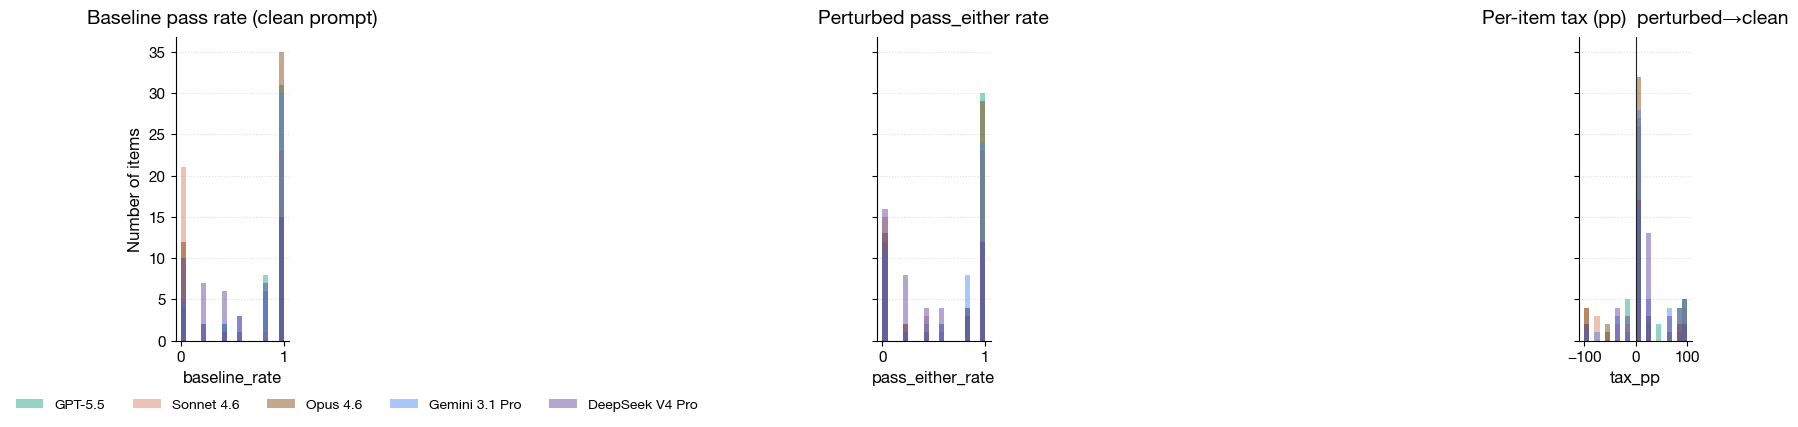

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

metrics = [
    ("baseline_rate",     "Baseline pass rate (clean prompt)",     (0, 1)),
    ("pass_either_rate",  "Perturbed pass_either rate",            (0, 1)),
    ("tax_pp",            "Per-item tax (pp)  perturbed→clean",    (-100, 100)),
]

for ax, (col, title, xlim) in zip(axes, metrics):
    for m in MODELS:
        sub = per_item[per_item["model"] == m][col]
        ax.hist(sub, bins=20, range=xlim, alpha=0.45,
                label=shorten_model_name(m), color=MODEL_COLORS[m])
    ax.set_title(title)
    ax.set_xlabel(col)

axes[0].set_ylabel("Number of items")
axes[-1].axvline(0, color="#222", linewidth=0.8)
axes[0].legend(loc="upper center", bbox_to_anchor=(1.6, -0.15), ncol=5, frameon=False)
plt.tight_layout()
plt.show()


In [7]:

# Per-model summary: mean / median / p25 / p75 of tax_pp
desc = (per_item.groupby("model")["tax_pp"]
                  .agg(["mean", "median",
                       lambda x: x.quantile(0.25),
                       lambda x: x.quantile(0.75),
                       "std", "count"])
                  .rename(columns={"<lambda_0>": "p25", "<lambda_1>": "p75"})
                  .reindex(MODELS).round(2))
print("Per-item tax_pp distribution (per model):")
desc


Per-item tax_pp distribution (per model):


,mean,median,p25,p75,std,count
model,,,,,,
gpt-5.5,10.83,0.0,0.0,20.0,46.85,48
claude-sonnet,-7.08,0.0,-20.0,0.0,49.59,48
claude-opus,6.67,0.0,0.0,0.0,48.17,48
gemini-3.1-pro,10.83,0.0,0.0,20.0,41.86,48
deepseek-v4-pro,11.25,0.0,0.0,20.0,42.05,48



## 3. Cross-model item-level agreement

For each of the 48 items, on how many of the 5 models did `pass_either` exceed 0.5? An item that "passes" all 5 is universally easy; one that fails all 5 is universally hard. The shape of this distribution tells us how much the benchmark's difficulty is item-driven vs model-driven.


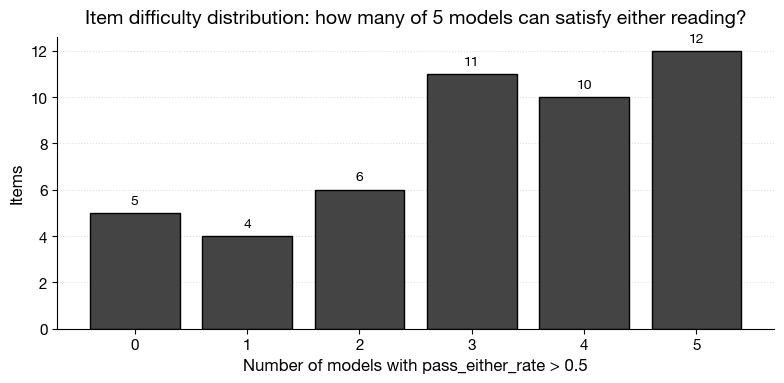


Items all 5 fail (universally hard): 5
Items all 5 pass (universally easy): 12
Items 1-4 pass (model-dependent): 31


In [8]:

# Per-item: how many models scored pass_either_rate > 0.5?
pe = per_item.pivot(index="task_id", columns="model", values="pass_either_rate")[MODELS]
n_models_passed = (pe > 0.5).sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
counts = n_models_passed.value_counts().reindex(range(0, len(MODELS) + 1), fill_value=0).sort_index()
ax.bar(counts.index, counts.values, color="#444", edgecolor="black")
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + 0.4, str(y), ha="center", fontsize=10)
ax.set_xlabel("Number of models with pass_either_rate > 0.5")
ax.set_ylabel("Items")
ax.set_xticks(range(0, len(MODELS) + 1))
ax.set_title("Item difficulty distribution: how many of 5 models can satisfy either reading?")
plt.tight_layout()
plt.show()

print(f"\nItems all 5 fail (universally hard): {(n_models_passed == 0).sum()}")
print(f"Items all 5 pass (universally easy): {(n_models_passed == 5).sum()}")
print(f"Items 1-4 pass (model-dependent): {((n_models_passed >= 1) & (n_models_passed <= 4)).sum()}")


In [9]:

# List the universally-hard and universally-easy items
hard = pe[n_models_passed == 0].index.tolist()
easy = pe[n_models_passed == len(MODELS)].index.tolist()
meta = (per_item[per_item["model"] == MODELS[0]]
        [["task_id", "anchor_task_id", "source", "ambiguity_type", "risk_level"]]
        .set_index("task_id"))

print(f"Universally-HARD items ({len(hard)}):")
print(meta.loc[hard].to_string() if hard else "  (none)")
print()
print(f"Universally-EASY items ({len(easy)}):")
print(meta.loc[easy].to_string() if easy else "  (none)")


Universally-HARD items (5):
             anchor_task_id  source ambiguity_type risk_level
task_id                                                      
AMBI/022  DS1000/Pandas/131  ds1000  coreferential       high
AMBI/024  DS1000/Pandas/104  ds1000  coreferential       high
AMBI/033    DS1000/Pandas/6  ds1000      syntactic       high
AMBI/040   DS1000/Pandas/62  ds1000         scopal       high
AMBI/056   DS1000/Pandas/60  ds1000     elliptical        low

Universally-EASY items (12):
             anchor_task_id     source           ambiguity_type risk_level
task_id                                                                   
AMBI/007           MBPP/399       mbpp  collective_distributive        low
AMBI/008           MBPP/425       mbpp  collective_distributive        low
AMBI/009           MBPP/433       mbpp                syntactic        low
AMBI/013            MBPP/63       mbpp  collective_distributive        low
AMBI/014            MBPP/69       mbpp  collective_distrib


## 4. Choice decomposition — where does the n_samples budget go?

For each model, what fraction of *samples* end up in each of the 4 mutually-exclusive buckets:
- **chose_a**: passed test_a but not test_b → model picked interpretation A
- **chose_b**: passed test_b but not test_a → model picked interpretation B
- **both**: passed both → tests cannot distinguish (unfortunate, but happens)
- **neither**: passed neither → model produced wrong / failing code

Headline shape: a model that handles ambiguity well has high (chose_a + chose_b) and low neither.


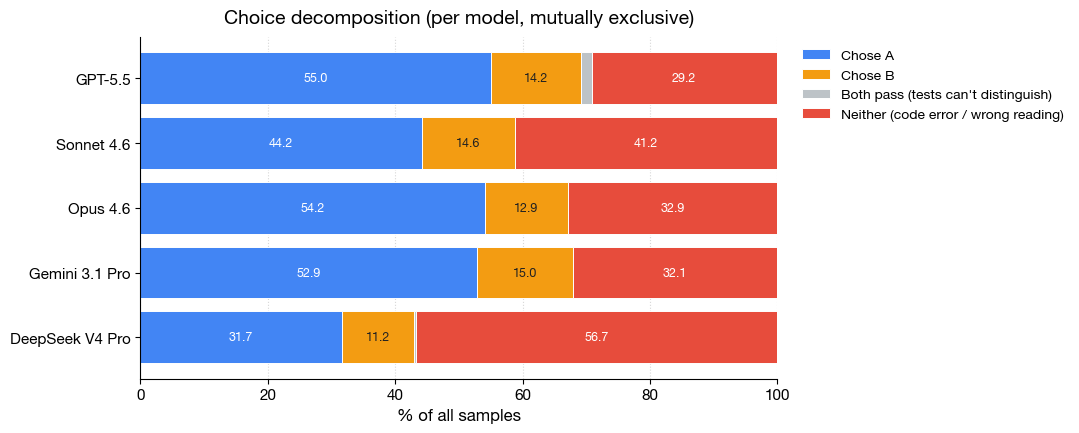


Decomposition (% of samples):


,chose_a%,chose_b%,both%,neither%
gpt-5.5,55.0,14.2,1.7,29.2
claude-sonnet,44.2,14.6,0.0,41.2
claude-opus,54.2,12.9,0.0,32.9
gemini-3.1-pro,52.9,15.0,0.0,32.1
deepseek-v4-pro,31.7,11.2,0.4,56.7


In [10]:

# Stacked horizontal bar of choice decomposition per model
fig, ax = plt.subplots(figsize=(11, 4.5))

cats = ["chose_a", "chose_b", "both", "neither"]
labels_pretty = {
    "chose_a": "Chose A",
    "chose_b": "Chose B",
    "both":    "Both pass (tests can't distinguish)",
    "neither": "Neither (code error / wrong reading)",
}
colors = {
    "chose_a": "#4285F4",
    "chose_b": "#F39C12",
    "both":    "#BDC3C7",
    "neither": "#E74C3C",
}

y = np.arange(len(MODELS))
left = np.zeros(len(MODELS))
for cat in cats:
    rate_field = "neither_rate" if cat == "neither" else f"{cat}_rate" if cat != "both" else "both_pass_rate"
    vals = np.array([summary["per_model"][m][rate_field] for m in MODELS]) * 100
    ax.barh(y, vals, left=left, color=colors[cat], edgecolor="white",
            linewidth=0.7, label=labels_pretty[cat])
    for yi, (l, v) in enumerate(zip(left, vals)):
        if v >= 4:
            ax.text(l + v/2, yi, f"{v:.1f}", ha="center", va="center", fontsize=9,
                    color="white" if cat in {"chose_a", "neither"} else "#222",
                    fontweight="bold")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels([shorten_model_name(m) for m in MODELS])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of all samples")
ax.set_title("Choice decomposition (per model, mutually exclusive)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Tabular form
decomp = pd.DataFrame({
    m: {
        "chose_a%":  summary["per_model"][m]["chose_a_rate"] * 100,
        "chose_b%":  summary["per_model"][m]["chose_b_rate"] * 100,
        "both%":     summary["per_model"][m]["both_pass_rate"] * 100,
        "neither%":  summary["per_model"][m]["neither_rate"] * 100,
    } for m in MODELS
}).T.round(1).reindex(MODELS)
print("\nDecomposition (% of samples):")
decomp



## 5. Failure mode dissection — what's *in* the "neither" pile?

A sample that satisfied neither test_a nor test_b can fail for distinct reasons:

- **parse error** — generated_code is empty or unparseable
- **timeout** — sandbox timed out
- **runtime error** — code ran but raised an exception (NameError, TypeError, …)
- **assertion failed** — code ran cleanly but produced the wrong output (wrong reading / brittle test schema)

Knowing the breakdown matters: an "assertion failed" share is real ambiguity-induced wrong reading; a "runtime error" share is plumbing.


In [11]:

def classify_failure(s: pd.Series) -> str:
    # Return the failure category for a sample that didn't pass either test.
    if s["passed_a"] or s["passed_b"]:
        return "passed"
    code = s.get("generated_code", "") or ""
    if not code.strip() or len(code.strip()) < 5:
        return "parse_or_empty"
    if s.get("timed_out_a") or s.get("timed_out_b"):
        return "timeout"
    stderr_a = (s.get("stderr_a") or "").lower()
    stderr_b = (s.get("stderr_b") or "").lower()
    runtime_markers = ("nameerror", "typeerror", "valueerror", "attributeerror",
                       "keyerror", "indexerror", "modulenotfounderror", "importerror",
                       "syntaxerror", "zerodivisionerror", "recursionerror")
    if any(mk in stderr_a or mk in stderr_b for mk in runtime_markers):
        return "runtime_error"
    if "assertionerror" in stderr_a or "assertionerror" in stderr_b:
        return "assertion_failed"
    return "other"


fail = samples[~(samples["passed_a"] | samples["passed_b"])].copy()
fail["fail_cat"] = fail.apply(classify_failure, axis=1)

# Per-model breakdown (% of failed samples)
fail_pivot = (fail.groupby(["model", "fail_cat"]).size()
                   .unstack(fill_value=0)
                   .reindex(MODELS))
fail_pivot["TOTAL_FAILED"] = fail_pivot.sum(axis=1)
fail_pivot_pct = (fail_pivot.iloc[:, :-1].div(fail_pivot["TOTAL_FAILED"], axis=0) * 100).round(1)
fail_pivot_pct["TOTAL_FAILED"] = fail_pivot["TOTAL_FAILED"]
print("Failure category breakdown (% of FAILED samples per model):")
fail_pivot_pct


Failure category breakdown (% of FAILED samples per model):


fail_cat,assertion_failed,other,parse_or_empty,runtime_error,TOTAL_FAILED
model,,,,,
gpt-5.5,72.9,15.7,0.0,11.4,70
claude-sonnet,60.6,18.2,0.0,21.2,99
claude-opus,75.9,6.3,0.0,17.7,79
gemini-3.1-pro,46.8,6.5,16.9,29.9,77
deepseek-v4-pro,55.1,6.6,5.1,33.1,136


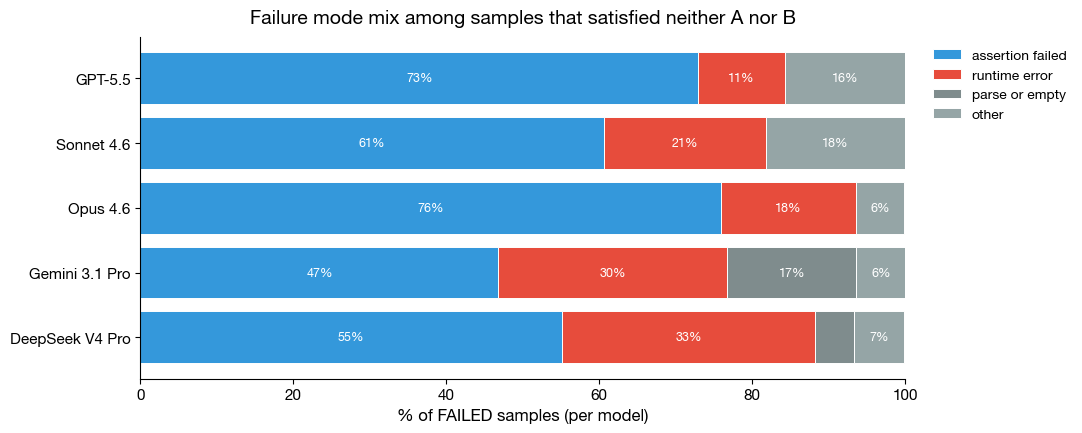

In [12]:

# Bar chart of failure mode mix per model
fail_cats = ["assertion_failed", "runtime_error", "timeout", "parse_or_empty", "other"]
fc_colors = {
    "assertion_failed": "#3498DB",   # blue — wrong reading
    "runtime_error":    "#E74C3C",   # red  — plumbing
    "timeout":          "#9B59B6",
    "parse_or_empty":   "#7F8C8D",
    "other":            "#95A5A6",
}

fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(MODELS))
left = np.zeros(len(MODELS))
for cat in fail_cats:
    if cat not in fail_pivot_pct.columns:
        continue
    vals = fail_pivot_pct[cat].reindex(MODELS).fillna(0).values
    ax.barh(y, vals, left=left, color=fc_colors[cat], edgecolor="white",
            linewidth=0.7, label=cat.replace("_", " "))
    for yi, (l, v) in enumerate(zip(left, vals)):
        if v >= 6:
            ax.text(l + v/2, yi, f"{v:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels([shorten_model_name(m) for m in MODELS])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of FAILED samples (per model)")
ax.set_title("Failure mode mix among samples that satisfied neither A nor B")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
plt.tight_layout()
plt.show()



**Reading.** The blue ("assertion failed") share is the proper "wrong-reading" failure — the code ran but produced output matching neither A nor B. The red ("runtime error") share is plumbing noise we should reduce in future iterations (especially in DS-1000, where NameError on `df` / `X` is a recurring story).



## 6. AC sample gallery — every clarification question across all 5 models

AC samples are rare (0–1.7% per model). All of them fit on a few screens. We dump the full prose / question for each, so we can read them.


In [13]:

ac = samples[samples["behavior_label"] == "AC"].sort_values(["model", "task_id"])
print(f"Total AC samples across all models: {len(ac)}")
print(f"Per model: {ac.groupby('model').size().to_dict()}")


Total AC samples across all models: 9
Per model: {'claude-opus': 2, 'deepseek-v4-pro': 3, 'gemini-3.1-pro': 4}


In [14]:

# Print one entry per AC sample
def render_ac(row):
    print("─" * 80)
    print(f"  {row['model']:<20}  {row['task_id']:<12}  ({row['ambiguity_type']}, {row['source']})")
    print(f"  PERTURBED PROMPT:")
    print("    " + (row["perturbed_prompt"] or "")[:400].replace("\n", "\n    "))
    print(f"  INTERP_A: {row['interpretation_a'][:160]}")
    print(f"  INTERP_B: {row['interpretation_b'][:160]}")
    print(f"  MODEL OUTPUT (raw response):")
    raw = row["raw_response"] or ""
    print("    " + raw[:600].replace("\n", "\n    "))
    print()

for _, r in ac.iterrows():
    render_ac(r)


────────────────────────────────────────────────────────────────────────────────
  claude-opus           AMBI/017      (coreferential, ds1000)
  PERTURBED PROMPT:
    Problem:
    
    I am using KMeans in sklearn on a data set which has more than 5000 samples. I want to find the p^th cluster center and the global centroid, and get the 50 samples (not just index but full data) closest to it as an output.
    Anyone can help me?
    
    A:
    
    <code>
    import numpy as np
    import pandas as pd
    from sklearn.cluster import KMeans
    p, X = load_data()
    assert type(X) == np.ndarray
    km = KMeans()
  INTERP_A: The pronoun 'it' refers to the p^th cluster center, meaning the output should be the 50 samples closest to that specific cluster center.
  INTERP_B: The pronoun 'it' refers to the global centroid, meaning the output should be the 50 samples closest to the overall mean of the entire dataset.
  MODEL OUTPUT (raw response):
    @@CODE_START@@
    def g(p, X, km):
     


## 7. EA sample gallery — what assumptions do models declare?

EA samples are more common (6–17% per model). We can't enumerate all, but we sample 2 per model and look at the *prose* field — that's the model's declaration of which reading it picked.


In [15]:

import random
random.seed(42)

ea = samples[samples["behavior_label"] == "EA"].copy()
print(f"Total EA samples: {len(ea)}\n")

# Sample up to 2 per model, spread across ambiguity types if possible
selected = []
for m in MODELS:
    sub = ea[ea["model"] == m]
    if len(sub) == 0:
        continue
    pick = sub.sample(min(2, len(sub)), random_state=42)
    selected.extend(pick.to_dict("records"))

for r in selected:
    print("─" * 80)
    print(f"  {r['model']:<20}  {r['task_id']:<12}  ({r['ambiguity_type']}, "
          f"passed_a={r['passed_a']}, passed_b={r['passed_b']})")
    code_str = (r["generated_code"] or "")[:400]
    prose_str = (r["prose"] or "")[:400]
    if prose_str.strip():
        print(f"  PROSE: {prose_str[:300].replace(chr(10), ' ')}")
    print(f"  CODE (first 400 chars):")
    print("    " + code_str.replace("\n", "\n    "))
    print()


Total EA samples: 146

────────────────────────────────────────────────────────────────────────────────
  gpt-5.5               AMBI/048      (collective_distributive, passed_a=True, passed_b=False)
  CODE (first 400 chars):
    def find_even_pair(A):
        """Count pairs of integers in a list whose XOR is even.
    
        The XOR of two integers is even when both integers have the same parity
        (both even or both odd).
        """
        even_count = 0
        odd_count = 0
    
        for num in A:
            if num % 2 == 0:
                even_count += 1
            else:
                odd_count += 1
    
        return (even_count * (even_count - 1) // 2) + (o

────────────────────────────────────────────────────────────────────────────────
  gpt-5.5               AMBI/039      (scopal, passed_a=True, passed_b=False)
  CODE (first 400 chars):
    def even_binomial_Coeff_Sum(n):
        """Takes a positive integer n and returns the sum of the even-indexed
        bi


## 8. Hardest / easiest / most-variable items

Three slices:
- **Hardest** = highest mean tax across 5 models
- **Easiest** = lowest mean tax (most negative)
- **Most variable** = highest std of tax across models — these reveal *interaction* between item and model


In [16]:

tax_mat = per_item.pivot(index="task_id", columns="model", values="tax_pp")[MODELS]
tax_summary = pd.DataFrame({
    "mean_tax": tax_mat.mean(axis=1).round(1),
    "std_tax":  tax_mat.std(axis=1).round(1),
}).join(meta)

print("TOP 8 hardest items (highest mean tax):")
print(tax_summary.sort_values("mean_tax", ascending=False).head(8).to_string())
print()
print("TOP 8 easiest items (lowest / most negative mean tax):")
print(tax_summary.sort_values("mean_tax").head(8).to_string())
print()
print("TOP 8 most VARIABLE items (highest std across models):")
print(tax_summary.sort_values("std_tax", ascending=False).head(8).to_string())


TOP 8 hardest items (highest mean tax):
          mean_tax  std_tax      anchor_task_id  source           ambiguity_type risk_level
task_id                                                                                    
AMBI/043      84.0     35.8   DS1000/Pandas/255  ds1000  collective_distributive        low
AMBI/040      76.0     43.4    DS1000/Pandas/62  ds1000                   scopal       high
AMBI/049      60.0     54.8   DS1000/Pandas/230  ds1000  collective_distributive        low
AMBI/033      56.0     45.6     DS1000/Pandas/6  ds1000                syntactic       high
AMBI/022      44.0     51.8   DS1000/Pandas/131  ds1000            coreferential       high
AMBI/019      36.0     51.8  DS1000/Pytorch/935  ds1000            coreferential        low
AMBI/056      36.0     53.7    DS1000/Pandas/60  ds1000               elliptical        low
AMBI/036      32.0     36.3   DS1000/Pandas/179  ds1000                   scopal        low

TOP 8 easiest items (lowest / most nega


**Read with caveat.** "Hardest" items are tax-positive across the board — they should be the headline items in the poster. "Easiest" items are tax-negative across the board — these may be benchmark artifacts (Stage-1 perturbation accidentally clarifying a vague clean prompt). "Most variable" items are where a specific model's reading bias kicks in — useful for failure case studies.



## 9. Sonnet negative-tax anomaly drill-down

The milestone notebook flagged Sonnet's negative tax. Here we triangulate: per-item, how does Sonnet's tax compare to the **mean of the other 4 models**? Items where Sonnet diverges the most from peers are the ones to investigate.


In [17]:

# Per-item: Sonnet's tax minus mean of the other 4 models
others = [m for m in MODELS if m != "claude-sonnet"]
peer_mean = tax_mat[others].mean(axis=1)
delta = (tax_mat["claude-sonnet"] - peer_mean).rename("sonnet_minus_peers")

frame = pd.concat([tax_mat[["claude-sonnet"]].rename(columns={"claude-sonnet": "sonnet_tax"}),
                    peer_mean.rename("peers_mean_tax"), delta], axis=1).join(meta)
frame = frame.sort_values("sonnet_minus_peers")

print("Top 8 items where Sonnet is HELPED MORE than peers (negative delta):")
print(frame.head(8)[["sonnet_tax", "peers_mean_tax", "sonnet_minus_peers",
                     "ambiguity_type", "anchor_task_id"]].round(1).to_string())
print()
print("Top 8 items where Sonnet is HURT MORE than peers (positive delta):")
print(frame.tail(8)[["sonnet_tax", "peers_mean_tax", "sonnet_minus_peers",
                     "ambiguity_type", "anchor_task_id"]].round(1).to_string())


Top 8 items where Sonnet is HELPED MORE than peers (negative delta):
          sonnet_tax  peers_mean_tax  sonnet_minus_peers           ambiguity_type     anchor_task_id
task_id                                                                                             
AMBI/026      -100.0            40.0              -140.0                syntactic  DS1000/Pandas/244
AMBI/058      -100.0            30.0              -130.0               elliptical   DS1000/Numpy/322
AMBI/056       -40.0            55.0               -95.0               elliptical   DS1000/Pandas/60
AMBI/040         0.0            95.0               -95.0                   scopal   DS1000/Pandas/62
AMBI/051       -80.0            10.0               -90.0  collective_distributive   DS1000/Pandas/75
AMBI/057       -80.0             5.0               -85.0               elliptical   DS1000/Numpy/388
AMBI/038      -100.0           -25.0               -75.0                   scopal   DS1000/Numpy/376
AMBI/015       -80.0  

In [18]:

# For ONE of the most extreme negative-delta items, dump the actual generated code from each model
target = frame.head(1).index[0]
print(f"Drilling into {target} (anchor: {meta.loc[target, 'anchor_task_id']})")
print(f"Type: {meta.loc[target, 'ambiguity_type']}, Source: {meta.loc[target, 'source']}")
print()

item_samples = samples[samples["task_id"] == target]
prompts_done = set()
for m in MODELS:
    rows_m = item_samples[item_samples["model"] == m]
    if rows_m.empty:
        continue
    if m not in prompts_done:
        # Print the perturbed prompt only once
        if not prompts_done:
            print("PERTURBED PROMPT:")
            print("  " + (rows_m.iloc[0]["perturbed_prompt"] or "")[:500].replace("\n", "\n  "))
            print()
            print(f"INTERP_A: {rows_m.iloc[0]['interpretation_a'][:200]}")
            print(f"INTERP_B: {rows_m.iloc[0]['interpretation_b'][:200]}")
            print()
        prompts_done.add(m)
    # Dump first sample's code from this model
    s = rows_m.iloc[0]
    print(f"── {m}  (sample 0)  passed_a={s['passed_a']}, passed_b={s['passed_b']}, label={s['behavior_label']} ──")
    print("  " + (s["generated_code"] or "")[:500].replace("\n", "\n  "))
    print()


Drilling into AMBI/026 (anchor: DS1000/Pandas/244)
Type: syntactic, Source: ds1000

PERTURBED PROMPT:
  Problem:
  I would like to aggregate user transactions into lists in pandas. I can't figure out how to make a list comprised of more than one field.
  
  Given a DataFrame like this,
  
  
  df = pd.DataFrame({'user':[1,1,2,2,3], 
                     'time':[20,10,11,18,15], 
                     'amount':[10.99,4.99,2.99,1.99,10.99]})
  
  I learned I can do something like
  
  
  df.groupby('user').agg(lambda x: x.tolist())
  
  but I'm going to want to sort time and amounts in the same order for each user with transactio

INTERP_A: Create, for each user, a single column whose values are lists of [time, amount] pairs taken from the original row order.
INTERP_B: Create, for each user with transactions in a list, sorted time and amount lists in the same order rather than paired [time, amount] rows.

── gpt-5.5  (sample 0)  passed_a=False, passed_b=False, label=SA ──
  def g(df):
   


## 10. Latency profile — what's the wall-clock cost of each model?

Per-sample latency (seconds). Mean / median / p95 give us a sense of how much
slower reasoning models are.


In [19]:

lat = (samples.groupby("model")["latency_s"]
                  .agg(["mean", "median",
                       lambda x: x.quantile(0.95),
                       "max", "count"])
                  .rename(columns={"<lambda_0>": "p95"})
                  .reindex(MODELS).round(2))
print("Per-sample latency (seconds):")
lat


Per-sample latency (seconds):


,mean,median,p95,max,count
model,,,,,
gpt-5.5,11.08,10.19,23.66,58.90,240
claude-sonnet,3.70,3.10,7.77,15.06,240
claude-opus,3.79,3.34,9.19,13.80,240
gemini-3.1-pro,30.32,24.09,67.20,165.77,240
deepseek-v4-pro,50.01,39.48,120.68,300.32,240


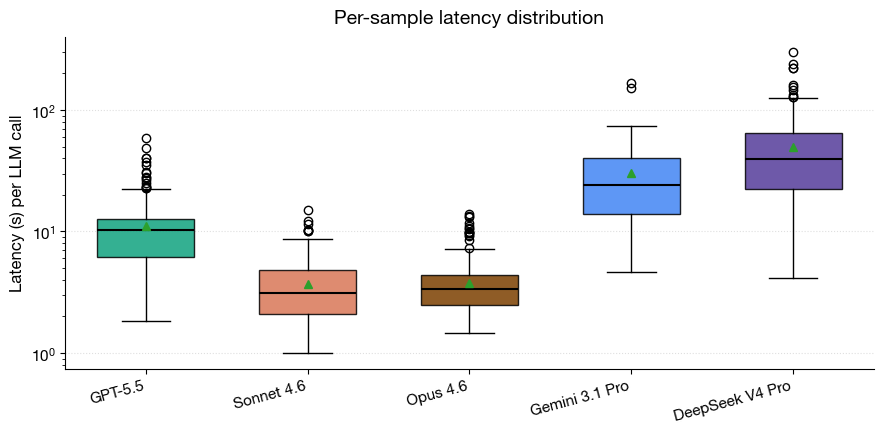

In [20]:

# Per-model latency boxplot
fig, ax = plt.subplots(figsize=(9, 4.5))
data = [samples[samples["model"] == m]["latency_s"].values for m in MODELS]
bp = ax.boxplot(data, patch_artist=True, showmeans=True, widths=0.6,
                medianprops=dict(color="black", linewidth=1.5))
for patch, m in zip(bp["boxes"], MODELS):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)
ax.set_xticklabels([shorten_model_name(m) for m in MODELS], rotation=15, ha="right")
ax.set_ylabel("Latency (s) per LLM call")
ax.set_title("Per-sample latency distribution")
ax.set_yscale("log")
plt.tight_layout()
plt.show()



## 11. Interpretation-B pickup analysis

Headline finding: A-bias is 73-81%. But on which items does *anyone* actually pick interpretation B? What types?


In [21]:

# For each item, count how many of the 5 models picked B at least once
b_count_per_item = (per_item.assign(picked_b=lambda d: d["chose_b_count"] > 0)
                              .groupby("task_id")["picked_b"].sum())

print(f"Items where ≥1 model picked B at least once: "
      f"{(b_count_per_item >= 1).sum()}/{len(b_count_per_item)}")
print(f"Items where ≥3 models picked B at least once: "
      f"{(b_count_per_item >= 3).sum()}")
print()

b_friendly = b_count_per_item[b_count_per_item >= 3].index
print("Items where 3+ models successfully picked B (B-friendly items):")
print(meta.loc[b_friendly].to_string())


Items where ≥1 model picked B at least once: 19/48
Items where ≥3 models picked B at least once: 8

Items where 3+ models successfully picked B (B-friendly items):
             anchor_task_id  source           ambiguity_type risk_level
task_id                                                                
AMBI/006           MBPP/391    mbpp  collective_distributive        low
AMBI/021   DS1000/Scipy/740  ds1000            coreferential        low
AMBI/023  DS1000/Pandas/240  ds1000            coreferential       high
AMBI/026  DS1000/Pandas/244  ds1000                syntactic        low
AMBI/030  DS1000/Pandas/277  ds1000                syntactic        low
AMBI/035           MBPP/162    mbpp                   scopal        low
AMBI/038   DS1000/Numpy/376  ds1000                   scopal        low
AMBI/062           MBPP/307    mbpp               elliptical       high


In [22]:

# Among (model, item) combos that have chose_b > 0, what's the distribution by ambiguity_type?
b_picked = per_item[per_item["chose_b_count"] > 0]
print("(model, item) pairs where B was picked at least once, by ambiguity_type:")
ct = b_picked.groupby(["ambiguity_type", "model"]).size().unstack(fill_value=0).reindex(columns=MODELS, fill_value=0)
ct["TOTAL"] = ct.sum(axis=1)
ct


(model, item) pairs where B was picked at least once, by ambiguity_type:


model,gpt-5.5,claude-sonnet,claude-opus,gemini-3.1-pro,deepseek-v4-pro,TOTAL
ambiguity_type,,,,,,
collective_distributive,1,2,1,1,2,7
coreferential,2,2,2,2,2,10
elliptical,1,3,2,1,1,8
scopal,2,2,2,1,4,11
syntactic,2,3,1,4,3,13



## 12. Open questions / next experiments

1. **Sonnet anomaly mechanism.** Hypotheses to test:
   - (a) **Brittle baseline + diverse sampling**. Re-run baseline ONLY for Sonnet at n=20 on the negative-delta items; if Sonnet's baseline variance is much higher than others, hypothesis (a) is supported.
   - (b) **Paraphrase robustness**. Compare Sonnet's per-item baseline to the others' baselines. If Sonnet's clean-prompt pass rate is systematically lower while others are higher on the *same* items, hypothesis (b) gets a vote.
2. **Reasoning vs non-reasoning AC gap.** Add Qwen 3.6 Plus (reasoning) and re-evaluate. If AC remains 0% for Qwen, the "reasoning → AC > 0" claim weakens; if it sits at 1–2%, the claim strengthens.
3. **Test schema brittleness in DS-1000.** §5 should report the exact fraction of failures attributable to runtime / NameError / wrong-format. If it's > 30% of failures on DS-1000, the v3 priority is rewriting tests with format tolerance.
4. **B-friendly items audit.** The handful of items where multiple models successfully picked B (§11) tell us where the perturbation is genuinely two-way. Pull these into a "controlled-difficulty" subset and re-compute A-bias.
5. **A-bias controlled subset.** Re-compute A-bias only on items where Stage-2 entropy ≈ 1 (genuine bilateral ambiguity). If A-bias drops from 73–81% to ~50%, the residual bias is construction artifact.
6. **n_samples sensitivity.** Bootstrap CIs span 25 pp at n=5. At n=10 we'd expect tighter; one model at n=10 (probably gpt-5.5) would calibrate how much bigger an effect we're missing.
